## Methods Used in Evacuation Research

### Comparison Table

| Method | Strengths | Weaknesses | Validation maturity |
|---|---|---|---|
| Social Force (SFM) | Captures local interactions, bottleneck effects, arching/clogging; interpretable mechanics | Parameter-sensitive; can misfit real high-stress flow unless calibrated | Medium-High |
| Cellular Automata / Floor-Field | Very fast, scalable, easy scenario sweeps | Grid artifacts; behavior realism can be crude without many extensions | Medium |
| Rule-based ABM | Flexible behavior logic, route choice, social interactions | Modeler-bias risk; rule explosion; calibration burden | Medium |
| Continuum/macroscopic (Hughes-type) | Efficient for very large crowds and strategic flow patterns | Coarse individual behavior, weaker local interaction fidelity | Medium |
| ORCA/RVO velocity-avoidance | Excellent real-time collision avoidance, decentralized | Not an evacuation behavior theory by itself; weak for panic/social decision dynamics | Low-Medium (for evac behavior) |
| Fire-coupled evac (e.g., FDS+Evac) | Couples smoke/fire + movement + decision processes; practical for engineering | Heavier setup; still needs strong scenario-specific V&V | High (engineering use) |
| Generative/LLM-augmented ABM (GABM-like) | Rich heterogeneous behavior, what-if social logic | Highest validation burden, reproducibility/explainability concerns | Low-Medium |

### Aims of this notebook
- To do literature research on further models and papers, and identify which is the most suitable approach to use for evacuation modelling
- As much as possible, compare the pros & cons as well as use papers that have based research on real life data.
- In doing so, provide more direction in which to better pivot and organise future simulation projects during this internship


### Paper 1: Sticco, Frank, Dorso (2020/2021) — Black Friday crowd video

**Reference**

Sticco, Frank, Dorso (2020/2021) 
*Social Force Model parameter testing and optimization using a high stress real-life situation*  
- arXiv: https://arxiv.org/abs/2007.06651  
- Physica A DOI: https://doi.org/10.1016/j.physa.2020.125299

**What is this paper about?**

Real video of a Nike store opening (South Africa, Nov 2017), treated as emergency-like high-stress ingress.

Model use: Escape-panic SFM; compared multiple literature parameter sets; then optimized contact-related parameters (k_t, k_n) with Differential Evolution.

Key finding: Lab-calibrated sets tended to evacuate too fast versus real video curve; physical-contact terms were critical in dense aggressive flow.

Strength: Strong reality check for high-stress crowding; explicitly shows calibration transfer problem.

Limitation: Single event/context; parameter non-uniqueness (different parameter combos fit similarly). Also not a real emergency - it's about the hype over a store opening & the crowd 'rushing in', not 'rushing out'

### What this paper did
- Used real video from a Black Friday store opening (South Africa, Nov 2017).
- Measured high ingress flow: **⟨J⟩ = 6.7 ± 0.8 persons/s**.
- Compared simulation curves against empirical ingress curve.
- Found standard/lab parameter sets can be too optimistic (simulated flow too fast).
- Optimized contact-related parameters (`k_t`, `k_n`) to better match empirical behavior.

### What we replicate here
- We reproduce the **calibration logic** (fit simulation to target flow/curve).
- Our local `pysocialforce` implementation does **not expose** `k_t`, `k_n` directly.
- So we calibrate available proxies:
  - `social_force.factor`
  - `obstacle_force.factor`
  - `panic_speed` (initial desired speed)
- Output metrics:
  - cumulative entrants over time
  - entrants per second (flow)
  - final entered fraction

In [1]:
%pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\kylet\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# 1.1: setup
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tempfile
import toml

REPO = Path(r"C:\Users\kylet\HTX\Deliverable 1\FYP-Generative-Agent-Evacuation-Simulation")
EXPERIMENTS = REPO / "experiments"
BASE_CONFIG = EXPERIMENTS / "example.toml"

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import pysocialforce as psf

np.random.seed(42)

**1.2: Geometry + Config Helpers**

This cell defines:
- a corridor/barrier geometry with a doorway (Black-Friday-style ingress bottleneck),
- temporary config writing (so we can sweep parameters),
- initialization helpers for starting crowd positions

In [3]:
def write_temp_config(
    base_config_path,
    social_force_factor=5.1,
    obstacle_force_factor=10.0,
    max_speed_multiplier=1.3,
    tau=0.5
):
    cfg = toml.load(base_config_path)

    cfg.setdefault("scene", {})
    cfg["scene"]["max_speed_multiplier"] = float(max_speed_multiplier)
    cfg["scene"]["tau"] = float(tau)

    cfg.setdefault("social_force", {})
    cfg["social_force"]["factor"] = float(social_force_factor)

    cfg.setdefault("obstacle_force", {})
    cfg["obstacle_force"]["factor"] = float(obstacle_force_factor)

    f = tempfile.NamedTemporaryFile(delete=False, suffix=".toml")
    tmp_path = Path(f.name)
    f.close()

    with open(tmp_path, "w", encoding="utf-8") as fp:
        toml.dump(cfg, fp)

    return tmp_path


def make_black_friday_obstacles(x_left=-10, x_right=10, half_height=4.0, door_width=2.0):
    # Corridor top/bottom + barrier at x=0 with doorway gap
    dh = door_width / 2.0
    return [
        [x_left, x_right,  half_height,  half_height],   # top wall
        [x_left, x_right, -half_height, -half_height],   # bottom wall
        [0.0, 0.0,  dh,  half_height],                   # barrier upper
        [0.0, 0.0, -half_height, -dh],                   # barrier lower
    ]


def sample_initial_left_side(n_agents, x_min=-9.0, x_max=-1.0, y_min=-3.7, y_max=3.7):
    return np.column_stack([
        np.random.uniform(x_min, x_max, n_agents),
        np.random.uniform(y_min, y_max, n_agents),
    ])

**1.3: Single Simulation Runner**

This cell runs one ingress simulation and records:
- cumulative entrants over time,
- instantaneous flow (persons/s),
- final entered fraction,
- optional sampled trajectories.

In [4]:
# Single simulation run (ingress flow tracking)
def run_black_friday_once(
    n_agents=120,
    door_width=2.0,
    panic_speed=2.2,
    social_force_factor=5.1,
    obstacle_force_factor=10.0,
    max_steps=300,
    tau=0.5,
    seed=42,
    record_traj=False,
    traj_every=10,
):
    np.random.seed(seed)

    obstacles = make_black_friday_obstacles(door_width=door_width)
    pos0 = sample_initial_left_side(n_agents=n_agents)

    goal = np.array([8.5, 0.0])  # inside store direction
    goals = np.tile(goal, (n_agents, 1))

    vel0 = np.zeros((n_agents, 2))
    for i in range(n_agents):
        d = goal - pos0[i]
        d = d / np.linalg.norm(d)
        vel0[i] = d * panic_speed

    init = np.zeros((n_agents, 6), dtype=float)
    init[:, :2] = pos0
    init[:, 2:4] = vel0
    init[:, 4:6] = goals

    cfg_path = write_temp_config(
        BASE_CONFIG,
        social_force_factor=social_force_factor,
        obstacle_force_factor=obstacle_force_factor,
        tau=tau
    )

    sim = psf.Simulator(
        init,
        groups=None,
        obstacles=obstacles,
        config_file=cfg_path
    )

    # Use simulator step width as the true integration time.
    dt = float(sim.peds.step_width)

    # More robust threshold for doorway crossing.
    gate_x = 0.0
    crossed = np.zeros(n_agents, dtype=bool)
    prev_entered = 0

    rows = []
    traj_rows = []

    for step in range(max_steps + 1):
        cur_pos = sim.peds.pos()
        cur_x = cur_pos[:, 0]

        # Mark entered once agent reaches/passes gate_x.
        crossed = crossed | (cur_x >= gate_x)

        entered_count = int(crossed.sum())
        new_entries = entered_count - prev_entered
        prev_entered = entered_count

        rows.append({
            "step": step,
            "time_s": step * dt,
            "new_entries": new_entries,
            "entered_count": entered_count,
            "entered_fraction": entered_count / n_agents,
            "inst_flow_p_s": (new_entries / dt) if dt > 0 else np.nan,
            "x_max": float(cur_x.max()),
            "x_mean": float(cur_x.mean()),
        })

        if record_traj and (step % traj_every == 0):
            for i in range(n_agents):
                traj_rows.append({
                    "step": step,
                    "time_s": step * dt,
                    "agent_id": i,
                    "x": float(cur_pos[i, 0]),
                    "y": float(cur_pos[i, 1]),
                })

        if step < max_steps:
            sim.step(1)

    curve = pd.DataFrame(rows)
    traj = pd.DataFrame(traj_rows)

    # active ingress window
    active = curve[curve["entered_count"] > 0]
    if len(active) > 1:
        duration = active["time_s"].iloc[-1] - active["time_s"].iloc[0]
        total_entered_in_window = active["entered_count"].iloc[-1] - active["entered_count"].iloc[0]
        mean_flow_active = total_entered_in_window / duration if duration > 0 else np.nan
    else:
        mean_flow_active = np.nan

    summary = {
        "n_agents": n_agents,
        "door_width": door_width,
        "panic_speed": panic_speed,
        "social_force_factor": social_force_factor,
        "obstacle_force_factor": obstacle_force_factor,
        "max_steps": max_steps,
        "tau": tau,
        "dt": dt,
        "gate_x": gate_x,
        "final_entered_count": int(curve["entered_count"].iloc[-1]),
        "final_entered_fraction": float(curve["entered_fraction"].iloc[-1]),
        "mean_flow_active_p_s": float(mean_flow_active) if pd.notna(mean_flow_active) else np.nan,
        "peak_flow_p_s": float(curve["inst_flow_p_s"].max()),
        "max_x_reached": float(curve["x_max"].max()),
    }

    return curve, traj, summary


**1.4: Baseline Run**

This cell runs 1 reference simulation & plots:
1. Cumulative entered count vs time
2. Flow vs time, with paper benchmark band (6.7 ± 0.8 p/s).

Purpose: sanity check whetehr default parameters are too fast/slow

DEBUG:[byteflow.py:81             __init__() ] bytecode dump:
>          0	NOP(arg=None, lineno=97)
           2	RESUME(arg=0, lineno=97)
           4	LOAD_FAST(arg=0, lineno=101)
           6	LOAD_CONST(arg=1, lineno=101)
           8	LOAD_CONST(arg=1, lineno=101)
          10	BUILD_SLICE(arg=2, lineno=101)
          12	LOAD_CONST(arg=2, lineno=101)
          14	LOAD_CONST(arg=3, lineno=101)
          16	BUILD_SLICE(arg=2, lineno=101)
          18	BUILD_TUPLE(arg=2, lineno=101)
          20	BINARY_SUBSCR(arg=None, lineno=101)
          24	STORE_FAST(arg=1, lineno=101)
          26	LOAD_GLOBAL(arg=1, lineno=102)
          36	LOAD_ATTR(arg=2, lineno=102)
          56	LOAD_FAST(arg=1, lineno=102)
          58	GET_ITER(arg=None, lineno=102)
          60	LOAD_FAST_AND_CLEAR(arg=2, lineno=102)
          62	SWAP(arg=2, lineno=102)
          64	BUILD_LIST(arg=0, lineno=102)
          66	SWAP(arg=2, lineno=102)
>         68	FOR_ITER(arg=33, lineno=102)
          72	STORE_FAST(arg=2, lineno=102

n_agents                  120.000000
door_width                  2.000000
panic_speed                 2.200000
social_force_factor         5.100000
obstacle_force_factor      10.000000
max_steps                 300.000000
tau                         0.500000
dt                          0.050000
gate_x                      0.000000
final_entered_count       120.000000
final_entered_fraction      1.000000
mean_flow_active_p_s        8.178694
peak_flow_p_s              60.000000
max_x_reached              11.157983
dtype: float64
Entered max: 120 | Max x reached: 11.157983138950295


DEBUG:[font_manager.py:1483     _findfont_cached() ] findfont: score(FontEntry(fname='C:\\Users\\kylet\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSansMono-BoldOblique.ttf', name='DejaVu Sans Mono', style='oblique', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
DEBUG:[font_manager.py:1483     _findfont_cached() ] findfont: score(FontEntry(fname='C:\\Users\\kylet\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXNonUniBolIta.ttf', name='STIXNonUnicode', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
DEBUG:[font_manager.py:1483     _findfont_cached() ] findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\msjh.ttc', name='Microsoft JhengHei', style='normal', variant='norm

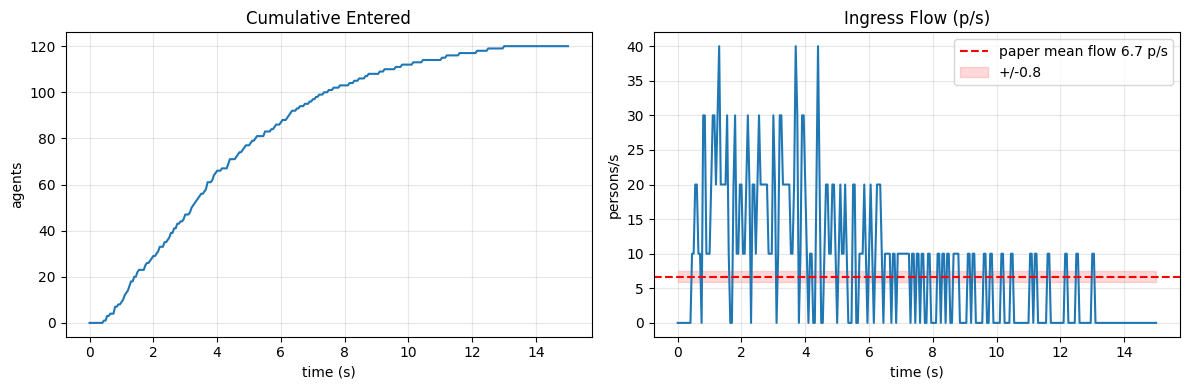

In [5]:
# 1.4: quick baseline run + visualize
curve0, traj0, s0 = run_black_friday_once(
    n_agents=120,
    door_width=2.0,
    panic_speed=2.2,
    social_force_factor=5.1,
    obstacle_force_factor=10.0,
    max_steps=300,
    tau=0.5,
    seed=101,
    record_traj=True,
    traj_every=10
)

print(pd.Series(s0))
print("Entered max:", int(curve0["entered_count"].max()), "| Max x reached:", float(curve0["x_max"].max()))

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(curve0["time_s"], curve0["entered_count"])
ax[0].set_title("Cumulative Entered")
ax[0].set_xlabel("time (s)")
ax[0].set_ylabel("agents")
ax[0].grid(True, alpha=0.3)

flow_roll = curve0["inst_flow_p_s"].rolling(2, min_periods=1).mean()  # ~2*dt smoothing
ax[1].plot(curve0["time_s"], flow_roll)
ax[1].axhline(6.7, ls="--", c="r", label="paper mean flow 6.7 p/s")
ax[1].fill_between(curve0["time_s"], 5.9, 7.5, color="r", alpha=0.15, label="+/-0.8")
ax[1].set_title("Ingress Flow (p/s)")
ax[1].set_xlabel("time (s)")
ax[1].set_ylabel("persons/s")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**1.5: Calibration Sweep**

This cell performs a small parameter sweep over:
- `social_force_factor`,
- `obstacle_force_factor`,
- `panic_speed`.

It ranks candidates by absolute error to the benchmark flow (6.7 p/s).

In [6]:
# 1.5: calibration sweep (small and practical)
TARGET_FLOW = 6.7
TARGET_TOL = 0.8

grid_social = [4.0, 5.1, 6.5]
grid_obstacle = [8.0, 10.0, 12.0]
grid_speed = [1.8, 2.2, 2.8]
seeds = [101, 102]  # keep light first

rows = []
for sf in grid_social:
    for of in grid_obstacle:
        for sp in grid_speed:
            run_summaries = []
            for sd in seeds:
                _, _, summ = run_black_friday_once(
                    n_agents=120,
                    door_width=2.0,
                    panic_speed=sp,
                    social_force_factor=sf,
                    obstacle_force_factor=of,
                    max_steps=300,
                    tau=0.5,
                    seed=sd,
                    record_traj=False
                )
                run_summaries.append(summ)

            d = pd.DataFrame(run_summaries)
            mean_flow = d["mean_flow_active_p_s"].mean()
            mean_entered_frac = d["final_entered_fraction"].mean()

            rows.append({
                "social_force_factor": sf,
                "obstacle_force_factor": of,
                "panic_speed": sp,
                "mean_flow_active_p_s": mean_flow,
                "mean_final_entered_fraction": mean_entered_frac,
                "flow_abs_error_vs_6p7": abs(mean_flow - TARGET_FLOW) if pd.notna(mean_flow) else np.nan,
                "inside_target_band": (TARGET_FLOW - TARGET_TOL <= mean_flow <= TARGET_FLOW + TARGET_TOL) if pd.notna(mean_flow) else False
            })

calib = pd.DataFrame(rows).sort_values(["flow_abs_error_vs_6p7", "mean_final_entered_fraction"])
calib.head(10)

,social_force_factor,obstacle_force_factor,panic_speed,mean_flow_active_p_s,mean_final_entered_fraction,flow_abs_error_vs_6p7,inside_target_band
18,6.5,8.0,1.8,7.883043,0.966667,1.183043,False
24,6.5,12.0,1.8,7.883043,0.966667,1.183043,False
21,6.5,10.0,1.8,7.986373,0.979167,1.286373,False
9,5.1,8.0,1.8,8.020737,0.983333,1.320737,False
12,5.1,10.0,1.8,8.020737,0.983333,1.320737,False
15,5.1,12.0,1.8,8.034697,0.983333,1.334697,False
2,4.0,8.0,2.8,8.068517,1.000000,1.368517,False
5,4.0,10.0,2.8,8.068517,1.000000,1.368517,False
8,4.0,12.0,2.8,8.068517,1.000000,1.368517,False
20,6.5,8.0,2.8,8.075039,1.000000,1.375039,False


**1.6: Best Candidate + Trajectories**

This cell reruns the top candidate and visualizes:
- final calibration metrics,
- sample trajectories (“where agents go”) through the doorway.

Best candidate summary:
n_agents                  120.000000
door_width                  2.000000
panic_speed                 1.800000
social_force_factor         6.500000
obstacle_force_factor       8.000000
max_steps                 300.000000
tau                         0.500000
dt                          0.050000
gate_x                      0.000000
final_entered_count       117.000000
final_entered_fraction      0.975000
mean_flow_active_p_s        7.945205
peak_flow_p_s              40.000000
max_x_reached              11.495146
dtype: float64


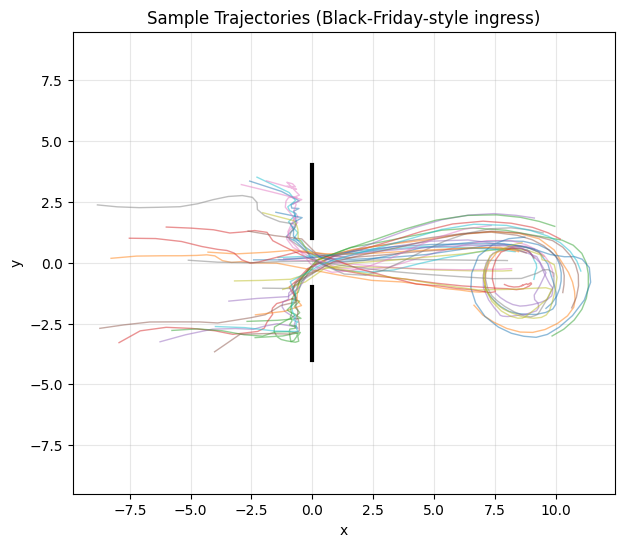

In [7]:
# 1.6: run best candidate and show trajectories ("where agents go")
best = calib.iloc[0]
curve_best, traj_best, summary_best = run_black_friday_once(
    n_agents=120,
    door_width=2.0,
    panic_speed=float(best["panic_speed"]),
    social_force_factor=float(best["social_force_factor"]),
    obstacle_force_factor=float(best["obstacle_force_factor"]),
    max_steps=300,
    tau=0.5,
    seed=999,
    record_traj=True,
    traj_every=10
)

print("Best candidate summary:")
print(pd.Series(summary_best))

# Sample trajectories
sample_agents = 30
ids = traj_best["agent_id"].drop_duplicates()
if len(ids) > sample_agents:
    ids = ids.sample(sample_agents, random_state=42)

plot_df = traj_best[traj_best["agent_id"].isin(ids)]

plt.figure(figsize=(7,6))
for aid, g in plot_df.groupby("agent_id"):
    plt.plot(g["x"], g["y"], alpha=0.5, lw=1)

# draw doorway lines
hh = 4.0
dw = 2.0
dh = dw / 2
plt.plot([0,0],[dh,hh],'k-',lw=3)
plt.plot([0,0],[-hh,-dh],'k-',lw=3)

plt.title("Sample Trajectories (Black-Friday-style ingress)")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

**1.7: Summary and Findings**

- We replicated the **calibration idea** from Sticco et al. by fitting simulated flow to the empirical target band (6.7 ± 0.8 p/s).
- Because this local implementation does not expose `k_t` and `k_n`, calibration was performed on available force/speed parameters instead.
- The experiment still demonstrates the same core message:
  - default parameter sets may over/under-estimate high-stress throughput,
  - and multiple parameter combinations can produce similarly good aggregate fit (identifiability issue).
- Therefore, parameter fit should be reported with uncertainty and not treated as unique truth.

**Comparison to NTU Paper**
- NTU Paper: synthetic room setup (20×20, single exit), baseline/behavioral/group comparison, behavior grid from LLM, mostly internal validation.
- shifts to external benchmarking using a real-event target flow (Black Friday paper reports about 6.7 ± 0.8 p/s) and calibrates model parameters to match observed ingress trend.
- Net effect: Stronger on empirical grounding than FYP baseline-vs-behavior comparison.

### Paper 2: Ya’an Earthquake Classroom Evacuation (Li et al., 2015)

**Reference**
- Li et al. (2015), *Safety Science*  
- Topic: parameter calibration of SFM using real 2013 Ya’an earthquake classroom evacuation video.

**What this section does**
1. Build a classroom-style evacuation setup.
2. Define a data-driven calibration loop (fit to empirical evacuation curve).
3. Compare intervention scenarios:
   - single-exit vs back-door-open (2 exits)
   - no-leader vs leader-guided proxy
   - comparisons between 3-5-2, 3-4-3 and 2-5-3 classroom layouts (left side closest to the door)

**2.1: Imports & Paths**

But since this has already been done in section 1.1, we don't need to do it again since the constants are used. We can skip that

**2.2: Constants**

This cell creates sets the constants (in the paper, a maximum number of agents, 66: 65 students + 1 teacher, the classroom and desk dimensions) - modelling each worst-case scenario actively

In [8]:
CLASS_W = 6.6  # width (y direction)
CLASS_D = 9.0  # depth (x direction)
DESK_D = 0.55  # desk side along x
DESK_W = 0.42  # desk size along y

N_STUDENTS = 65
N_TEACHER = 1
N_AGENTS = N_STUDENTS + N_TEACHER

**2.3: Geometry Helpers**

This cell defines low-level geometry utilities:
- rectangle-to-line-segment conversion,
- temporary config writer for parameter sweeps.

In [9]:
# 2.3 geometry helpers
def rect_segments(cx, cy, dx, dy):
    x0, x1 = cx - dx/2, cx + dx/2
    y0, y1 = cy - dy/2, cy + dy/2
    return [
        [x0, x1, y0, y0],
        [x0, x1, y1, y1],
        [x0, x0, y0, y1],
        [x1, x1, y0, y1],
    ]

def write_temp_config(base_config_path, social_force_factor=5.1, obstacle_force_factor=10.0, max_speed_multiplier=1.3):
    cfg = toml.load(base_config_path)
    cfg.setdefault("social_force", {})
    cfg.setdefault("obstacle_force", {})
    cfg.setdefault("scene", {})
    cfg["social_force"]["factor"] = float(social_force_factor)
    cfg["obstacle_force"]["factor"] = float(obstacle_force_factor)
    cfg["scene"]["max_speed_multiplier"] = float(max_speed_multiplier)

    f = tempfile.NamedTemporaryFile(delete=False, suffix=".toml")
    tmp_path = Path(f.name)
    f.close()
    with open(tmp_path, "w", encoding="utf-8") as fp:
        toml.dump(cfg, fp)
    return tmp_path

**2.4 Classroom Layout Generator (2-5-3 / 3-4-3 / 3-5-2)**

This cell generates:
- desk-centered seating positions for students,
- teacher start position,
- desk obstacles for collision/flow effects.

Purpose:
- model internal layout effects explicitly, not just random initial positions.

In [10]:
# 2.4 layout builder: desks + seated positions
def parse_layout_code(layout_code):
    return [int(x) for x in layout_code.split("-")]

def build_y_slots(layout_counts, desk_w=DESK_W, seat_gap=0.10, aisle_w=0.80):
    ys = []
    y = 0.0
    for bi, cnt in enumerate(layout_counts):
        for _ in range(cnt):
            ys.append(y)
            y += desk_w + seat_gap
        if bi < len(layout_counts) - 1:
            y += aisle_w
    ys = np.array(ys, dtype=float)
    ys = ys - ys.mean()  # center
    return ys

def generate_classroom_layout(layout_code="3-5-2", n_students=65,
                              class_w=CLASS_W, class_d=CLASS_D,
                              desk_d=DESK_D, desk_w=DESK_W,
                              row_gap=0.30, back_margin=0.75, front_margin=1.20,
                              seat_offset_x=0.20):
    counts = parse_layout_code(layout_code)               # e.g., [3,5,2]
    seats_per_row = sum(counts)
    n_rows = int(np.ceil(n_students / seats_per_row))

    y_slots = build_y_slots(counts, desk_w=desk_w, seat_gap=0.10, aisle_w=0.80)
    y_slots = np.clip(y_slots, -class_w/2 + 0.35, class_w/2 - 0.35)

    # rows from back (+x) to front (-x), left side closer to door
    x_back = class_d/2 - back_margin
    x_front_limit = -class_d/2 + front_margin
    x_rows = np.linspace(x_back, x_front_limit, n_rows)

    desk_centers = []
    student_positions = []

    k = 0
    for xr in x_rows:
        for y in y_slots:
            if k >= n_students:
                break
            desk_centers.append((xr, y))
            # student starts slightly behind desk center (towards back)
            sx = xr + seat_offset_x
            student_positions.append((sx, y))
            k += 1
        if k >= n_students:
            break

    # teacher near front center
    teacher_pos = np.array([[x_front_limit - 0.4, 0.0]], dtype=float)

    # desks as obstacles
    desk_obstacles = []
    for cx, cy in desk_centers:
        desk_obstacles.extend(rect_segments(cx, cy, desk_d, desk_w))

    return np.array(student_positions, dtype=float), teacher_pos, desk_obstacles

**2.5 Classroom Walls and Exit Configuration**

This cell creates classroom boundaries and door openings:
- single main door on left wall (top left),
- optional back door on opposite wall for 2-exit scenarios.

In [11]:
# 2.5 Classroom walls + same-side door configuration
def classroom_walls_same_side(class_w=CLASS_W, class_d=CLASS_D, door_w=1.2, two_doors=False, end_margin=0.55):
    # x in [-D/2, D/2], y in [-W/2, W/2]
    xL, xR = -class_d/2, class_d/2
    yB, yT = -class_w/2, class_w/2
    dh = door_w / 2

    # Door centers on LEFT wall at opposite ends
    y_low = yB + end_margin + dh
    y_high = yT - end_margin - dh

    walls = [
        [xL, xR, yB, yB],   # bottom
        [xL, xR, yT, yT],   # top
        [xR, xR, yB, yT],   # right wall full
    ]

    if two_doors:
        # left wall split into 3 solid parts, with 2 gaps
        gaps = sorted([(y_low - dh, y_low + dh), (y_high - dh, y_high + dh)])
        cursor = yB
        for g0, g1 in gaps:
            if g0 > cursor:
                walls.append([xL, xL, cursor, g0])
            cursor = g1
        if cursor < yT:
            walls.append([xL, xL, cursor, yT])
    else:
        # single door at lower end (main door)
        g0, g1 = y_low - dh, y_low + dh
        walls += [
            [xL, xL, yB, g0],
            [xL, xL, g1, yT],
        ]

    return walls, {"y_low": y_low, "y_high": y_high, "x_left": xL}

**2.6 Layout-Aware Simulation Runner**

This cell runs one classroom simulation and returns:
- evacuation curve over time (`evac_count`, `evac_fraction`),
- final summary metrics.

Inputs include:
- layout code,
- door configuration,
- movement/force parameters.

In [12]:
# 2.6 Layout-aware simulation runner (same-side doors on left wall)
def run_classroom_once(
    layout_code="3-5-2",
    n_students=65,
    door_w=1.2,
    back_door_open=False,      # False: single door; True: two doors on same left wall
    panic_speed=1.8,
    social_force_factor=5.1,
    obstacle_force_factor=10.0,
    max_steps=600,
    seed=42,
    teacher_speed_mult=1.05,
    stall_limit=120,
):
    np.random.seed(seed)

    # 1) Build classroom population + desks
    student_pos, teacher_pos, desk_obs = generate_classroom_layout(
        layout_code=layout_code,
        n_students=n_students
    )
    pos0 = np.vstack([student_pos, teacher_pos])  # 65 + 1 = 66 agents

    # 2) Build walls with one/two doors on the SAME left wall
    walls, door_info = classroom_walls_same_side(
        class_w=CLASS_W,
        class_d=CLASS_D,
        door_w=door_w,
        two_doors=back_door_open,
        end_margin=0.55
    )
    obstacles = walls + desk_obs

    # 3) Build goals
    x_exit = door_info["x_left"] - 2.0
    if back_door_open:
        # assign each agent to nearest of the 2 left-wall doors
        goal_low = np.array([x_exit, door_info["y_low"]], dtype=float)
        goal_high = np.array([x_exit, door_info["y_high"]], dtype=float)

        d_low = np.linalg.norm(pos0 - goal_low, axis=1)
        d_high = np.linalg.norm(pos0 - goal_high, axis=1)

        goals = np.zeros((len(pos0), 2), dtype=float)
        low_mask = d_low <= d_high
        goals[low_mask] = goal_low
        goals[~low_mask] = goal_high
    else:
        # single door (lower-end left door)
        goals = np.tile(np.array([x_exit, door_info["y_low"]], dtype=float), (len(pos0), 1))

    # 4) Initial velocities towards assigned goals
    vel0 = np.zeros((len(pos0), 2), dtype=float)
    for i in range(len(pos0)):
        d = goals[i] - pos0[i]
        d = d / np.linalg.norm(d)
        v = panic_speed
        if i == len(pos0) - 1:   # teacher is last row in pos0
            v *= teacher_speed_mult
        vel0[i] = d * v

    # 5) Init SFM state
    init = np.zeros((len(pos0), 6), dtype=float)
    init[:, :2] = pos0
    init[:, 2:4] = vel0
    init[:, 4:6] = goals

    # 6) Write temp config and run simulator
    cfg = write_temp_config(
        BASE_CONFIG,
        social_force_factor=social_force_factor,
        obstacle_force_factor=obstacle_force_factor
    )

    sim = psf.Simulator(init, groups=None, obstacles=obstacles, config_file=cfg)
    dt = float(sim.peds.step_width)

    # 7) Evacuation counting
    # considered evacuated when agent crosses the left boundary plane
    crossed = np.zeros(len(pos0), dtype=bool)
    x_left_boundary = -CLASS_D / 2

    rows = []
    last_evac = 0
    stall_counter = 0

    for step in range(max_steps + 1):
        cur_pos = sim.peds.pos()
        x = cur_pos[:, 0]

        crossed = crossed | (x <= x_left_boundary)

        evac_count = int(crossed.sum())
        rows.append({
            "step": step,
            "time_s": step * dt,
            "evac_count": evac_count,
            "evac_fraction": evac_count / len(pos0),
            "x_mean": float(x.mean()),
            "x_min": float(x.min())
        })

        # Early-stop rules for faster sweeps
        if evac_count > last_evac:
            stall_counter = 0
            last_evac = evac_count
        else:
            stall_counter += 1

        if evac_count == len(pos0):
            break
        if stall_counter >= stall_limit:
            break

        if step < max_steps:
            sim.step(1)

    curve = pd.DataFrame(rows)

    summary = {
        "layout_code": layout_code,
        "n_agents": len(pos0),
        "single_or_two_doors_left_wall": "two_doors" if back_door_open else "single_door",
        "door_w": door_w,
        "panic_speed": panic_speed,
        "social_force_factor": social_force_factor,
        "obstacle_force_factor": obstacle_force_factor,
        "final_evac_count": int(curve["evac_count"].iloc[-1]),
        "final_evac_fraction": float(curve["evac_fraction"].iloc[-1]),
        "dt": dt,
        "steps_executed": int(curve["step"].iloc[-1]),
    }

    return curve, summary


**2.7 Empirical Curve Input (Observed Data)**

This cell stores observed evacuation curve points (time vs evacuated fraction) extracted from the paper/video.

Notes:
- Replace placeholder points with your final digitized values.
- Keep `time_s` ascending.

In [13]:
# 2.7 empirical curve (replace with digitized points)
empirical = pd.DataFrame({
    "time_s": [0, 5, 10, 15, 20, 25, 30, 35, 40],
    "evac_fraction_obs": [0.00, 0.08, 0.22, 0.40, 0.58, 0.73, 0.85, 0.93, 0.98]
})

def rmse(a, b):
    a, b = np.asarray(a), np.asarray(b)
    return np.sqrt(np.mean((a - b) ** 2))

empirical

,time_s,evac_fraction_obs
0,0,0.00
1,5,0.08
2,10,0.22
3,15,0.40
4,20,0.58
5,25,0.73
6,30,0.85
7,35,0.93
8,40,0.98


**2.8 Calibration Sweep by Layout (Single-Door Baseline)**

This cell calibrates model parameters separately for each classroom layout:
- 2-5-3
- 3-4-3
- 3-5-2

Calibration target:
- minimize RMSE between simulated and observed evacuation-fraction curve.

Setup:
- single-door condition only (baseline),
- multiple seeds for robustness.

In [14]:
# 2.8 calibration sweep (fast pilot mode)
layouts = ["2-5-3", "3-4-3", "3-5-2"]

# Coarse grid first; refine top candidates later
grid_speed = [1.5, 1.8]
grid_sf = [4.5, 5.1]
grid_of = [8.0, 10.0]
seeds = [101]   # pilot pass; expand to [101,102,103] for final
MAX_STEPS_CAL = 600
STALL_LIMIT_CAL = 120

rows = []
for lay in layouts:
    for sp in grid_speed:
        for sf in grid_sf:
            for of in grid_of:
                errs = []
                for sd in seeds:
                    sim_curve, _ = run_classroom_once(
                        layout_code=lay,
                        n_students=65,
                        door_w=1.2,
                        back_door_open=False,   # single-door calibration baseline
                        panic_speed=sp,
                        social_force_factor=sf,
                        obstacle_force_factor=of,
                        max_steps=MAX_STEPS_CAL,
                        stall_limit=STALL_LIMIT_CAL,
                        seed=sd
                    )

                    m = empirical.merge(sim_curve[["time_s", "evac_fraction"]], on="time_s", how="left")
                    m["evac_fraction"] = m["evac_fraction"].interpolate().bfill().ffill()
                    errs.append(rmse(m["evac_fraction_obs"], m["evac_fraction"]))

                rows.append({
                    "layout_code": lay,
                    "panic_speed": sp,
                    "social_force_factor": sf,
                    "obstacle_force_factor": of,
                    "rmse_mean": float(np.mean(errs)),
                    "rmse_std": float(np.std(errs)),
                })

calib_df = pd.DataFrame(rows).sort_values(["layout_code", "rmse_mean"]).reset_index(drop=True)
calib_df.head(12)


C:\Users\kylet\AppData\Local\Temp\ipykernel_45068\3112054297.py:32: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  m = empirical.merge(sim_curve[["time_s", "evac_fraction"]], on="time_s", how="left")
C:\Users\kylet\AppData\Local\Temp\ipykernel_45068\3112054297.py:32: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  m = empirical.merge(sim_curve[["time_s", "evac_fraction"]], on="time_s", how="left")
C:\Users\kylet\AppData\Local\Temp\ipykernel_45068\3112054297.py:32: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  m = empirical.merge(sim_curve[["time_s", "evac_fraction"]], on="time_s", how="left")
C:\Users\kylet\AppData\Local\Temp\ipykernel_45068\3112054297.py:32: UserWarning: You are merging on int and float columns where the float values are not equal to their int rep

,layout_code,panic_speed,social_force_factor,obstacle_force_factor,rmse_mean,rmse_std
0,2-5-3,1.8,4.5,8.0,0.424934,0.0
1,2-5-3,1.8,5.1,8.0,0.435302,0.0
2,2-5-3,1.8,4.5,10.0,0.456672,0.0
3,2-5-3,1.8,5.1,10.0,0.456672,0.0
4,2-5-3,1.5,4.5,8.0,0.478793,0.0
5,2-5-3,1.5,5.1,8.0,0.478793,0.0
6,2-5-3,1.5,4.5,10.0,0.501567,0.0
7,2-5-3,1.5,5.1,10.0,0.501567,0.0
8,3-4-3,1.8,4.5,8.0,0.367014,0.0
9,3-4-3,1.8,5.1,8.0,0.375793,0.0


In [15]:
# 2.8b optional refinement pass (run only after fast pilot)
# Keep top 3 per layout from pilot and re-evaluate with 3 seeds
refine_seeds = [101, 102, 103]

top_candidates = (
    calib_df.groupby("layout_code", as_index=False, group_keys=False)
    .apply(lambda d: d.nsmallest(3, "rmse_mean"))
    .reset_index(drop=True)
)

rows_refined = []
for _, r in top_candidates.iterrows():
    errs = []
    for sd in refine_seeds:
        sim_curve, _ = run_classroom_once(
            layout_code=r["layout_code"],
            n_students=65,
            door_w=1.2,
            back_door_open=False,
            panic_speed=float(r["panic_speed"]),
            social_force_factor=float(r["social_force_factor"]),
            obstacle_force_factor=float(r["obstacle_force_factor"]),
            max_steps=MAX_STEPS_CAL,
            stall_limit=STALL_LIMIT_CAL,
            seed=sd,
        )

        m = empirical.merge(sim_curve[["time_s", "evac_fraction"]], on="time_s", how="left")
        m["evac_fraction"] = m["evac_fraction"].interpolate().bfill().ffill()
        errs.append(rmse(m["evac_fraction_obs"], m["evac_fraction"]))

    rows_refined.append({
        "layout_code": r["layout_code"],
        "panic_speed": float(r["panic_speed"]),
        "social_force_factor": float(r["social_force_factor"]),
        "obstacle_force_factor": float(r["obstacle_force_factor"]),
        "rmse_mean": float(np.mean(errs)),
        "rmse_std": float(np.std(errs)),
    })

calib_df_refined = pd.DataFrame(rows_refined).sort_values(["layout_code", "rmse_mean"]).reset_index(drop=True)
calib_df_refined


C:\Users\kylet\AppData\Local\Temp\ipykernel_45068\817291846.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.nsmallest(3, "rmse_mean"))
C:\Users\kylet\AppData\Local\Temp\ipykernel_45068\817291846.py:28: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  m = empirical.merge(sim_curve[["time_s", "evac_fraction"]], on="time_s", how="left")
C:\Users\kylet\AppData\Local\Temp\ipykernel_45068\817291846.py:28: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  m = empirical.merge(sim_curve[["time_s", "evac_fraction"]], on="time_s", how="left")

,layout_code,panic_speed,social_force_factor,obstacle_force_factor,rmse_mean,rmse_std
0,2-5-3,1.8,4.5,8.0,0.424934,0.000000e+00
1,2-5-3,1.8,5.1,8.0,0.435302,0.000000e+00
2,2-5-3,1.8,4.5,10.0,0.456672,0.000000e+00
3,3-4-3,1.8,4.5,8.0,0.367014,0.000000e+00
4,3-4-3,1.8,5.1,8.0,0.375793,5.551115e-17
5,3-4-3,1.8,5.1,10.0,0.384901,5.551115e-17
6,3-5-2,1.8,4.5,8.0,0.424200,0.000000e+00
7,3-5-2,1.8,5.1,8.0,0.434644,5.551115e-17
8,3-5-2,1.8,4.5,10.0,0.445301,5.551115e-17


**2.9 Best-Fit Parameters per Layout**

This cell selects the best (lowest-RMSE) parameter set for each layout.

In [16]:
# 2.9 pick best per layout
best_per_layout = (
    calib_df.loc[calib_df.groupby("layout_code")["rmse_mean"].idxmin()]
    .sort_values("layout_code")
    .reset_index(drop=True)
)

best_per_layout

,layout_code,panic_speed,social_force_factor,obstacle_force_factor,rmse_mean,rmse_std
0,2-5-3,1.8,4.5,8.0,0.424934,0.0
1,3-4-3,1.8,4.5,8.0,0.367014,0.0
2,3-5-2,1.8,4.5,8.0,0.424200,0.0


**2.10 Scenario Comparison (1 vs 2 Doors on Same Left Wall)**

Using each layout's best-fit parameters, this cell compares:
- single door on left wall
- 2 doors on the same left wall at opposite ends

(this is like testing each test case; with 1 or 2 doors)

In [17]:
# 2.10 run scenario comparison with best-fit params
scenarios = [
    {"name": "single_door_left_wall", "back_door_open": False},
    {"name": "two_doors_same_left_wall", "back_door_open": True},
]

all_curves = []
all_summary = []

for _, b in best_per_layout.iterrows():
    for sc in scenarios:
        c, s = run_classroom_once(
            layout_code=b["layout_code"],
            n_students=65,
            door_w=1.2,
            back_door_open=sc["back_door_open"],
            panic_speed=float(b["panic_speed"]),
            social_force_factor=float(b["social_force_factor"]),
            obstacle_force_factor=float(b["obstacle_force_factor"]),
            max_steps=1200,
            seed=999
        )
        c["layout_code"] = b["layout_code"]
        c["scenario"] = sc["name"]

        s["layout_code"] = b["layout_code"]
        s["scenario"] = sc["name"]

        all_curves.append(c)
        all_summary.append(s)

df_sc = pd.concat(all_curves, ignore_index=True)
df_sc_summary = pd.DataFrame(all_summary)

df_sc_summary[["layout_code", "scenario", "final_evac_count", "final_evac_fraction"]]

,layout_code,scenario,final_evac_count,final_evac_fraction
0,2-5-3,single_door_left_wall,18,0.272727
1,2-5-3,two_doors_same_left_wall,29,0.439394
2,3-4-3,single_door_left_wall,24,0.363636
3,3-4-3,two_doors_same_left_wall,34,0.515152
4,3-5-2,single_door_left_wall,18,0.272727
5,3-5-2,two_doors_same_left_wall,30,0.454545


**2.11: Plot Evacuation Fraction Curves by Layout and Scenario**

This cell visualizes evacuation progress over time for each layout.

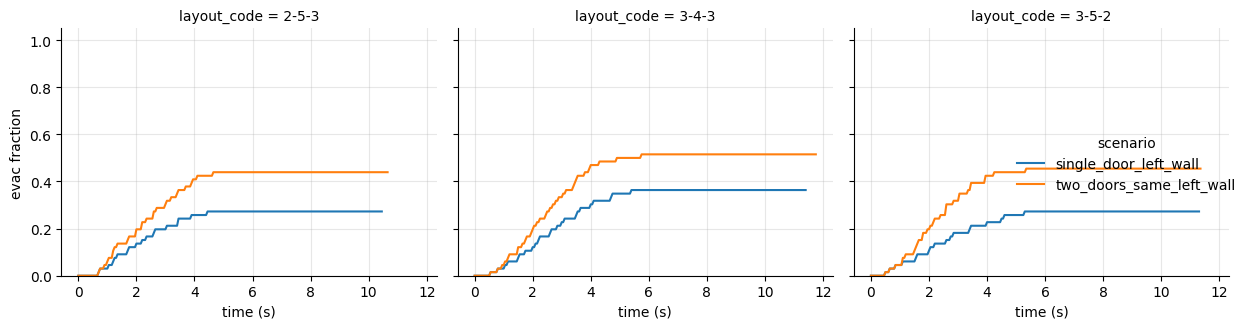

In [18]:
g = sns.FacetGrid(
    df_sc,
    col="layout_code",
    hue="scenario",
    col_wrap=3,
    height=3.4,
    sharey=True
)
g.map(plt.plot, "time_s", "evac_fraction")
g.add_legend()

for ax in g.axes.flat:
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("evac fraction")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**2.12: Plot Final Evacuation Fraction Comparison**

This cell shows the final evacuation outcome by layout/scenario in one chart.


INFO:[category.py:224               update() ] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:[category.py:224               update() ] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


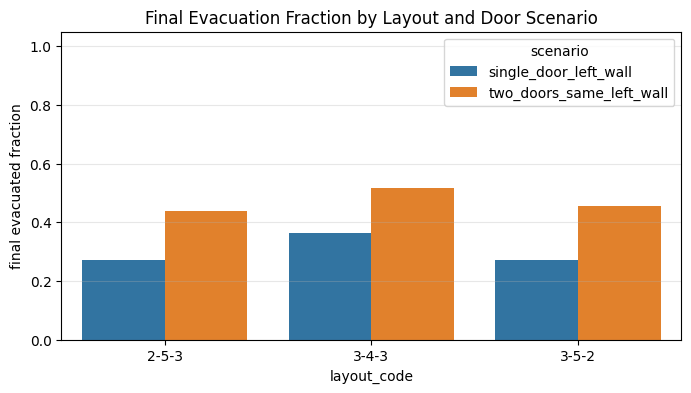

In [19]:
# 2.12 bar plot of final outcomes
plt.figure(figsize=(8, 4))
sns.barplot(data=df_sc_summary, x="layout_code", y="final_evac_fraction", hue="scenario")
plt.ylim(0, 1.05)
plt.ylabel("final evacuated fraction")
plt.title("Final Evacuation Fraction by Layout and Door Scenario")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

**2.13: Summary and Findings**
- Calibration was performed per layout under single-door baseline using RMSE to observed curve.
- Best-fit parameters differ by layout, indicating layout-specific flow effects.
- Under best-fit settings, adding a second door on the same wall generally improves evacuation completion/speed.
- Results should be reported with assumptions:
  - simplified decision behavior,
  - proxy leader dynamics (if used),
  - dependence on digitized empirical curve quality.

**Why is evacuation fraction so low?**
- It doesn’t reach 1.0 because not all 66 agents evacuate in that setup (many get stuck/congested).
- It “stops after ~4s” because evacuation progress stops there; after that the line is flat (and early-stop may end soon after).
- In your current geometry, the biggest cause is likely too-tight desk/aisle spacing for agent_radius=0.35, so flow jams early. In earthquake scenarios, this is likely to happen as the buildings or structure might shake or damage; making it impossible to escape or a better decision to stay in the classroom.

**Comparison with NTU Paper**
- NTU Paper: generic geometry and agent initialization, no direct disaster-specific geometry calibration.
- Paper-specific classroom assumptions (6.6m×9.0m, 66 agents, desk/layout variants), plus calibration logic to an observed evacuation curve and scenario tests (door strategy/layout effects).
- Net effect: Stronger on scenario realism and layout-specific testing.

### Paper 3 — FDS+Evac Paper Scenarios (Fast Proxy)

This section mirrors the VTT Sections 4–5 scenario style:
1. Public library (some exits blocked by smoke)
2. Large office (multiple exits, familiar route pressure)
3. Medium office (familiar route blocked, alternative exits)

**To keep runtime practical:**
- low `max_steps`
- low number of seeds
- primary metric: `escaped_fraction` over time (not full-completion time only)

**Reference / Citation**

Hostikka, S., Korhonen, T., Heliövaara, S., & Ehtamo, H. (2007).  
**Fire Dynamics Simulator with Evacuation: FDS+Evac Technical Reference and User’s Guide**.  
VTT (includes validation case studies with library and office-building evacuation drills).  
Link: [https://publications.vtt.fi/pdf/tiedotteet/2007/T2421.pdf](https://publications.vtt.fi/pdf/tiedotteet/2007/T2421.pdf)

**Does this take real-life data?**

Partly, yes.
- The source paper itself uses real evacuation drills and observed movement/route data. However, this is from a *drill*, not a real disaster where people are truly panicking & can behave very differently.
- In this notebook, we use a **proxy scenario mapping** (not full building CAD + full CFD smoke solution).
- So this section is best interpreted as **real-data-informed comparative simulation**, not a full forensic reconstruction.

**Pros**
- Strong practical grounding: based on validated FDS+Evac case-study workflow.
- Captures route-blocking and rerouting logic under smoke-affected conditions.
- Better engineering interpretability than pure behavior-only models.
- Faster scenario comparison when using proxy setup.

**Cons**
- Proxy implementation does not run full FDS smoke physics (temperature, toxicity, visibility fields from CFD).
- Geometry and occupant distributions are simplified vs real building layouts.
- Downscaled populations and capped time horizon can under-represent late-phase evacuation effects.
- Results should not be used as direct operational policy values without full FDS+Evac and site-specific calibration.

**Scope Note**

This section is an **FDS-informed fast proxy** for comparison and model selection under intern-time constraints.
For high-stakes deployment, rerun with full FDS+Evac geometry, fire/smoke boundary conditions, and calibration to measured drill data.

In [20]:
# 3.1: Pilot experiment settings
SEEDS = [101, 102]     # keep small first
MAX_STEPS = 400        # low runtime
STALL_LIMIT = 80       # early-stop when no progress
REPORT_TIMES = [5, 10, 15, 20]  # seconds

**Note:**

Most of section 3 follows the same format as 1 & 2. Hence, refer to these sections to get a description & understanding of what's going on; we are merely changing the parameters of the experiment

In [21]:
# 3.2: Geometry Helpers (rectangular building with selective open exits)
def make_rect_with_right_exits(width=20.0, height=12.0, exit_ys=(0.0,), door_w=1.2):
    """
    Rectangular room with exits on RIGHT wall only.
    Obstacles format: [x1, x2, y1, y2]
    """
    xL, xR = -width/2, width/2
    yB, yT = -height/2, height/2
    dh = door_w / 2

    # base walls
    walls = [
        [xL, xR, yB, yB],   # bottom
        [xL, xR, yT, yT],   # top
        [xL, xL, yB, yT],   # left
    ]

    # split right wall by exit gaps
    gaps = sorted([(y - dh, y + dh) for y in exit_ys])
    cursor = yB
    for g0, g1 in gaps:
        if g0 > cursor:
            walls.append([xR, xR, cursor, g0])
        cursor = g1
    if cursor < yT:
        walls.append([xR, xR, cursor, yT])

    return walls, xR

def sample_positions(n_agents, width, height, margin=0.8):
    return np.column_stack([
        np.random.uniform(-width/2 + margin, width/2 - margin, n_agents),
        np.random.uniform(-height/2 + margin, height/2 - margin, n_agents)
    ])

def assign_nearest_exit_goals(pos, exit_ys, exit_x):
    goals = np.zeros((len(pos), 2), dtype=float)
    for i, p in enumerate(pos):
        j = int(np.argmin(np.abs(np.array(exit_ys) - p[1])))
        goals[i] = np.array([exit_x + 2.0, exit_ys[j]])
    return goals

In [22]:
# 3.3: Scenario Runner (Escaped fraction over time)
def run_fds_proxy_case(
    case,
    seed=101,
    max_steps=400,
    stall_limit=80,
    base_speed=1.6,
):
    np.random.seed(seed)

    # case fields
    n_agents = case["n_agents"]
    width = case["width"]
    height = case["height"]
    door_w = case["door_w"]
    all_exit_ys = case["all_exit_ys"]
    blocked_exit_ids = set(case.get("blocked_exit_ids", []))

    open_exit_ys = [y for i, y in enumerate(all_exit_ys) if i not in blocked_exit_ids]
    if len(open_exit_ys) == 0:
        raise ValueError("No open exits in case")

    obstacles, x_right = make_rect_with_right_exits(width, height, open_exit_ys, door_w)
    pos0 = sample_positions(n_agents, width, height)
    goals = assign_nearest_exit_goals(pos0, open_exit_ys, x_right)

    vel0 = np.zeros((n_agents, 2))
    for i in range(n_agents):
        d = goals[i] - pos0[i]
        d = d / np.linalg.norm(d)
        vel0[i] = d * base_speed

    init = np.zeros((n_agents, 6), dtype=float)
    init[:, :2] = pos0
    init[:, 2:4] = vel0
    init[:, 4:6] = goals

    # reuse your section-2 helper
    cfg = write_temp_config(BASE_CONFIG, social_force_factor=5.1, obstacle_force_factor=10.0)
    sim = psf.Simulator(init, groups=None, obstacles=obstacles, config_file=cfg)
    dt = float(sim.peds.step_width)

    crossed = np.zeros(n_agents, dtype=bool)
    x_gate = x_right
    rows = []
    last = 0
    stall = 0

    for step in range(max_steps + 1):
        x = sim.peds.pos()[:, 0]
        crossed = crossed | (x >= x_gate)
        escaped = int(crossed.sum())

        rows.append({
            "step": step,
            "time_s": step * dt,
            "escaped_count": escaped,
            "escaped_fraction": escaped / n_agents
        })

        if escaped > last:
            last = escaped
            stall = 0
        else:
            stall += 1

        if escaped == n_agents or stall >= stall_limit:
            break

        sim.step(1)

    curve = pd.DataFrame(rows)
    summary = {
        "case_name": case["name"],
        "seed": seed,
        "n_agents": n_agents,
        "final_escaped_fraction": float(curve["escaped_fraction"].iloc[-1]),
        "final_escaped_count": int(curve["escaped_count"].iloc[-1]),
        "sim_time_s_end": float(curve["time_s"].iloc[-1])
    }
    return curve, summary

In [23]:
# 3.4: Define VTT Style Cases
# These are structural proxies of scenario types, not full building CAD replicas

# do let me know if you require me to do a full-volume test,
# i.e. no. of agents larger.
CASES = [
    {
        "name": "library_smoke_blocks_some_doors",
        "n_agents": 190,
        "width": 26.0,
        "height": 14.0,
        "door_w": 1.2,
        "all_exit_ys": [-5.0, -2.0, 0.0, 2.0, 5.0],  # multiple exits
        "blocked_exit_ids": [1, 3],                   # smoke-blocked pair
    },
    {
        "name": "large_office_7f_4entrances_proxy",
        "n_agents": 280,                              # downscaled from ~500 for runtime
        "width": 30.0,
        "height": 16.0,
        "door_w": 1.2,
        "all_exit_ys": [-6.0, -2.0, 2.0, 6.0],       # 4 entrances
        "blocked_exit_ids": [1],                      # one familiar route impaired
    },
    {
        "name": "medium_office_4f_5exits_proxy",
        "n_agents": 180,                              # downscaled from ~300
        "width": 24.0,
        "height": 14.0,
        "door_w": 1.2,
        "all_exit_ys": [-5.0, -2.5, 0.0, 2.5, 5.0],  # 5 exits
        "blocked_exit_ids": [2],                      # familiar central route blocked
    },
]

In [24]:
# 3.5: run all cases
all_curves = []
all_summary = []

for case in CASES:
    for sd in SEEDS:
        c, s = run_fds_proxy_case(
            case=case,
            seed=sd,
            max_steps=MAX_STEPS,
            stall_limit=STALL_LIMIT,
            base_speed=1.6
        )
        c["case_name"] = case["name"]
        c["seed"] = sd
        all_curves.append(c)
        all_summary.append(s)

df_s3_curve = pd.concat(all_curves, ignore_index=True)
df_s3_summary = pd.DataFrame(all_summary)
df_s3_summary

,case_name,seed,n_agents,final_escaped_fraction,final_escaped_count,sim_time_s_end
0,library_smoke_blocks_some_doors,101,190,0.878947,167,20.0
1,library_smoke_blocks_some_doors,102,190,0.878947,167,20.0
2,large_office_7f_4entrances_proxy,101,280,0.800000,224,20.0
3,large_office_7f_4entrances_proxy,102,280,0.810714,227,20.0
4,medium_office_4f_5exits_proxy,101,180,0.911111,164,20.0
5,medium_office_4f_5exits_proxy,102,180,0.916667,165,20.0


In [25]:
# 3.6: report fraction escaped at fixed times
def fraction_at_times(df_curve, report_times):
    out = []
    for (case_name, seed), g in df_curve.groupby(["case_name", "seed"]):
        g = g.sort_values("time_s")
        for t in report_times:
            idx = np.searchsorted(g["time_s"].values, t, side="right") - 1
            if idx < 0:
                frac = 0.0
                cnt = 0
            else:
                frac = float(g.iloc[idx]["escaped_fraction"])
                cnt = int(g.iloc[idx]["escaped_count"])
            out.append({
                "case_name": case_name,
                "seed": seed,
                "time_s": t,
                "escaped_fraction": frac,
                "escaped_count": cnt
            })
    return pd.DataFrame(out)

df_s3_timepoints = fraction_at_times(df_s3_curve, REPORT_TIMES)
df_s3_timepoints.head(12)

,case_name,seed,time_s,escaped_fraction,escaped_count
0,large_office_7f_4entrances_proxy,101,5,0.196429,55
1,large_office_7f_4entrances_proxy,101,10,0.457143,128
2,large_office_7f_4entrances_proxy,101,15,0.664286,186
3,large_office_7f_4entrances_proxy,101,20,0.800000,224
4,large_office_7f_4entrances_proxy,102,5,0.192857,54
5,large_office_7f_4entrances_proxy,102,10,0.450000,126
6,large_office_7f_4entrances_proxy,102,15,0.675000,189
7,large_office_7f_4entrances_proxy,102,20,0.810714,227
8,library_smoke_blocks_some_doors,101,5,0.236842,45
9,library_smoke_blocks_some_doors,101,10,0.526316,100


In [26]:
# 3.7: aggregate table for findings
s3_table = (
    df_s3_timepoints
    .groupby(["case_name", "time_s"], as_index=False)
    .agg(
        escaped_fraction_mean=("escaped_fraction", "mean"),
        escaped_fraction_std=("escaped_fraction", "std"),
        escaped_count_mean=("escaped_count", "mean")
    )
    .sort_values(["case_name", "time_s"])
)
s3_table

,case_name,time_s,escaped_fraction_mean,escaped_fraction_std,escaped_count_mean
0,large_office_7f_4entrances_proxy,5,0.194643,0.002525,54.5
1,large_office_7f_4entrances_proxy,10,0.453571,0.005051,127.0
2,large_office_7f_4entrances_proxy,15,0.669643,0.007576,187.5
3,large_office_7f_4entrances_proxy,20,0.805357,0.007576,225.5
4,library_smoke_blocks_some_doors,5,0.239474,0.003722,45.5
5,library_smoke_blocks_some_doors,10,0.534211,0.011165,101.5
6,library_smoke_blocks_some_doors,15,0.755263,0.003722,143.5
7,library_smoke_blocks_some_doors,20,0.878947,0.000000,167.0
8,medium_office_4f_5exits_proxy,5,0.308333,0.011785,55.5
9,medium_office_4f_5exits_proxy,10,0.611111,0.007857,110.0


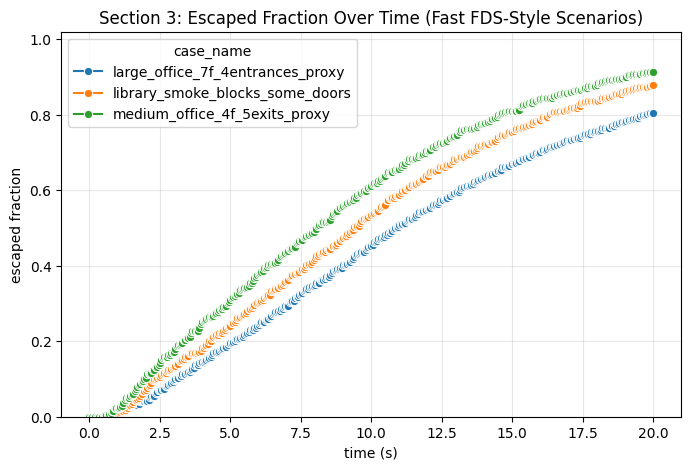

In [27]:
# 3.8: Plot escaped fraction curves
agg = (
    df_s3_curve.groupby(["case_name", "time_s"], as_index=False)
    .agg(escaped_fraction_mean=("escaped_fraction", "mean"))
)

plt.figure(figsize=(8,5))
sns.lineplot(data=agg, x="time_s", y="escaped_fraction_mean", hue="case_name", marker="o")
plt.ylim(0, 1.02)
plt.xlabel("time (s)")
plt.ylabel("escaped fraction")
plt.title("Section 3: Escaped Fraction Over Time (Fast FDS-Style Scenarios)")
plt.grid(True, alpha=0.3)
plt.show()

**3.9 Section 3 Findings (Short Write-up)**

- We report **escaped fraction over fixed times** to avoid waiting for full completion.
- Scenario differences are visible in early-phase slopes and final fraction by time cap.
- This provides a low-runtime comparative analysis aligned with VTT-style multi-scenario validation logic.

**Comparison Against `FYP.ipynb`**

- `FYP.ipynb` focuses on baseline vs behavioral (and later group) differences in a mostly generic single-room/single-exit setup, emphasizing personality-driven effects (e.g., impatience dynamics).
- Section 3 shifts focus to **environmental/operational stressors** (smoke-affected access, blocked/familiar routes, multi-exit behavior), which are closer to fire-engineering evacuation use cases.
- Compared to `FYP.ipynb`, Section 3 is less about “who behaves differently” and more about “how building/egress constraints change outcomes.”
- Methodologically, `FYP.ipynb` is stronger for behavioral heterogeneity experiments, while Section 3 is stronger for scenario realism and route-availability sensitivity.
- Practical implication: use `FYP.ipynb` findings for behavioral insight, but use Section 3-style analyses when discussing building safety planning and emergency route robustness.

### Conclusion

There is no single universally “best” model.  
For a **55,000-person emergency** scenario, the most suitable approach is:

1. **Primary engine:** calibrated **SFM / engineering evacuation model** (FDS+Evac-style logic for hazards and route constraints)  
2. **Scale strategy:** **multi-scale decomposition** (simulate by sectors/concourses rather than one monolithic crowd)  
3. **Behavior layer:** optional behavioral/group augmentation as a secondary sensitivity analysis, not the core decision model

**Why this is the most defensible choice**
- Pure behavioral/GABM models are rich but currently have higher validation uncertainty for policy-grade decisions.
- Pure CA is fast at scale but can oversimplify local crowd-pressure effects near bottlenecks.
- Calibrated SFM + engineering hazard logic provides the best balance of:
  - physical realism near exits/bottlenecks,
  - scenario interpretability,
  - practical validation pathway using drill/real-event data.

**Model suitability for large crowds (i.e. n_agents = 5-6 digits)**
- **Most suitable for planning use:**  
Calibrated SFM/FDS+Evac-informed framework with sector-level simulation and stitched system metrics.
- **Best for exploratory what-if behavior studies:**  
  Behavioral/GABM extension on top of calibrated baseline.
- **Not recommended as sole model for final safety claims:**  
  Uncalibrated behavioral-only or unvalidated synthetic setups.


### Bottlenecks (why simulation takes so long to run)
- TC1 uses n_agents=[50,100,500], MODELS=3, N_RUNS=3 → 27 runs.
- Each run executes full max_steps=800 (no early stop in run_timeseries).
- Social-force core is pairwise and has time complexity ~`O(N^2)` (explicitly noted in forces.py:255).
- With n=500, cost explodes:workload proxy ~ runs * steps * N^2
**9 * 800 * 500^2 ≈ 1.8B pairwise units** just for the 500-agent block.
- Trajectory logging is expensive, i.e. keep_traj_every=20 stores agent positions for every run/value/model.
- For TC1, roughly ~240k trajectory rows get created/concatenated/written.
Behavioral/group modes add overhead (dtype=object, trait generation, grouping logic).

### Why this notebook can run faster
- Section 2.8 was reduced to a coarse grid: 3 layouts * 2 * 2 * 2 * 1 seed = 24 runs.
- Lower agent counts (e.g. ~66 in Section 2's classroom setting). As time complexity of the simulation is O(n^2), it's exponentially faster to work with just 66 agents compared with 500
- Early-stop added (stall_limit) in run_classroom_once.
Section 3 uses capped steps (MAX_STEPS=400) + stall-stop + only 2 seeds.
No huge all-run trajectory dumps like the discrete notebook.

### Potential further extensions

- Get more real life datasets? There has been no evacuation study regarding terrorist attacks on crowds.
- Identify which is the best testing model (so far, I think these tests do things similarly, just with different datasets & parameters.) The papers largely share similar citations & references; so there aren't too many different models out there.
- Conduct my own study using SFM as the baseline. Need a calibrated baseline
    - Are there any videos/datasets I can calibrate SFM models to?
    - Videos that have crowds evacuating... try find as many as possible
    - Most common crowd videos: Shibuya scramble crossing - calibrate a baseline model that calibates how the crowds move
    - Coursework/paper that teaches how to do SFM calibration
    - How has the papers calibrated the speeds, the control factors. Is it possible to replicate calibration?
    - Algorithms to track video - obtain from JunKai
    - Try and run a simulation & parameters that don't take too long
    - Clean up the folder

### SFM Parameter Origins 

The 3 papers studied in this notebook rely on Helbing-style Social Force Model (SFM) assumptions, but they do not all calibrate from the exact same dataset. Helbing's work is best understood as a baseline parameterisation: some values come from empirical pedestrian-flow literature, while others are modelling constants chosen to reproduce observed crowd phenomena such as bottleneck flow, lane formation, clogging, and faster-is-slower effects.

| Parameter | Value used by Helbing | Where it came from / meaning |
|---|---:|---|
| Desired walking speed, normal crowds | mean `1.34 m/s`, SD `0.26 m/s` | From empirical pedestrian speed studies cited by Helbing, especially Weidmann/Navin-style pedestrian data |
| Max acceptable speed | `1.3 * desired speed` | Simulation cap used in the 1995 SFM formulation |
| Relaxation time `tau` | `0.5 s` | Reasonable estimate for how quickly pedestrians adapt toward desired velocity |
| Relaxed room-exit speed | approx `0.6 m/s` | Observed free velocities for leaving a room under relaxed conditions |
| Normal room-exit speed | approx `1.0 m/s` | Observed free velocities under normal conditions |
| Nervous condition speed | up to approx `1.5 m/s` | Threshold region where rush/clogging begins in the panic paper |
| Panic desired speed | can exceed `5 m/s`, up to `10 m/s` | Desired/intended speed, not necessarily achieved physical speed |
| Mass | `80 kg` | Average soccer-fan assumption in the escape panic paper |
| Pedestrian diameter | `0.5-0.7 m` | Approximation of shoulder-width variation |
| Bottleneck flow target | `0.73 persons/s` through effective `1 m` door at `v0 approx 0.8 m/s` | Used to fit repulsion constants |
| Repulsion constants `A`, `B` | `A=2000 N`, `B=0.08 m` | Chosen to reflect interpersonal distance and match bottleneck flow |
| Contact/friction constants `k`, `kappa` | `1.2e5`, `2.4e5` | Chosen to model body compression and sliding friction during physical contact |

### Source Links

- Helbing & Molnar (1995), **Social Force Model for Pedestrian Dynamics**: [arXiv](https://arxiv.org/abs/cond-mat/9805244), [DOI](https://doi.org/10.1103/PhysRevE.51.4282)
- Helbing, Farkas & Vicsek (2000), **Simulating Dynamical Features of Escape Panic**: [arXiv](https://arxiv.org/abs/cond-mat/0009448), [DOI](https://doi.org/10.1038/35035023)
- Helbing et al. simulation software note: [arXiv](https://arxiv.org/abs/cond-mat/0302021)

### Interpretation for This Project

Helbing-style parameters should be treated as calibrated priors, not universal constants. For scenario-specific claims, especially stadium or concert-scale emergency evacuation, the baseline SFM should be recalibrated against observed speed, flow, density, or evacuation-curve data from a similar context before adding behavioural or generative-agent extensions.
